# ¿Por qué estos jugadores tiran desde mid-range?

## Introducción

En el Notebook 2 analizamos la eficiencia por zona de los 4 outliers de mid-range identificados en la temporada 2024-25:

- **Kevin Durant** — 53.1% FG desde mid-range
- **Nikola Jokić** — 51.7% FG desde mid-range
- **Devin Booker** — 51.7% FG desde mid-range
- **Mikal Bridges** — 50.7% FG desde mid-range

Comprobamos que son jugadores por encima de la media NBA en la mayoría de zonas, pero, ¿por qué siguen tirando desde mid-range cuando la tendencia de la liga es abandonarlo?

## Objetivo del tercer Notebook

Responder dos preguntas:

1. **¿De dónde nace el lanzamiento?** — Tipo de acción que genera el lanzamiento desde mid-range
2. **¿Tiran con defensor encima?** — Distancia del defensor más cercano en sus mid-range

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import players
import pandas as pd

In [2]:
# No nos vamos a detener en esta parte, puesto que hay mucha similitud con el notebook 2 donde ya está explicado

jugadores = {
    "Kevin Durant": 201142,
    "Nikola Jokić": 203999,
    "Devin Booker": 1626164,
    "Mikal Bridges": 1628969
}

# La misma función que en el notebook 2
def get_shots_player(player_id, season):
    data = shotchartdetail.ShotChartDetail(
        team_id=0,
        player_id=player_id,
        context_measure_simple="FGA",
        season_nullable=season,
        season_type_all_star="Regular Season"
    ).get_data_frames()[0]
    data["SEASON"] = season
    return data

shots_por_jugador = {}
for nombre, player_id in jugadores.items():
    shots_por_jugador[nombre] = get_shots_player(player_id, "2024-25")

df = pd.concat(shots_por_jugador.values())
df

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,...,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,SEASON
0,Shot Chart Detail,0022400039,7,201142,Kevin Durant,1610612756,Phoenix Suns,1,11,37,...,24+ ft.,26,-192,188,1,1,20241126,PHX,LAL,2024-25
1,Shot Chart Detail,0022400039,41,201142,Kevin Durant,1610612756,Phoenix Suns,1,7,33,...,8-16 ft.,15,97,115,1,1,20241126,PHX,LAL,2024-25
2,Shot Chart Detail,0022400039,51,201142,Kevin Durant,1610612756,Phoenix Suns,1,6,25,...,8-16 ft.,14,105,106,1,0,20241126,PHX,LAL,2024-25
3,Shot Chart Detail,0022400039,149,201142,Kevin Durant,1610612756,Phoenix Suns,2,11,30,...,24+ ft.,26,107,238,1,0,20241126,PHX,LAL,2024-25
4,Shot Chart Detail,0022400039,170,201142,Kevin Durant,1610612756,Phoenix Suns,2,10,2,...,8-16 ft.,12,48,110,1,0,20241126,PHX,LAL,2024-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1178,Shot Chart Detail,0022401227,300,1628969,Mikal Bridges,1610612752,New York Knicks,2,2,44,...,Less Than 8 ft.,6,10,62,1,1,20241215,ORL,NYK,2024-25
1179,Shot Chart Detail,0022401227,314,1628969,Mikal Bridges,1610612752,New York Knicks,2,1,22,...,Less Than 8 ft.,4,29,36,1,0,20241215,ORL,NYK,2024-25
1180,Shot Chart Detail,0022401227,384,1628969,Mikal Bridges,1610612752,New York Knicks,3,6,26,...,Less Than 8 ft.,0,4,9,1,1,20241215,ORL,NYK,2024-25
1181,Shot Chart Detail,0022401227,398,1628969,Mikal Bridges,1610612752,New York Knicks,3,5,51,...,8-16 ft.,11,-109,18,1,1,20241215,ORL,NYK,2024-25


In [3]:
# Aunque lo tengamos en la documentación, dejamos aquí la lista para ver qué columnas nos interesan
# ACTION_TYPE y SHOT_ZONE_BASIC son las interesantes para lo que queremos estudiar
df.columns.tolist()

['GRID_TYPE',
 'GAME_ID',
 'GAME_EVENT_ID',
 'PLAYER_ID',
 'PLAYER_NAME',
 'TEAM_ID',
 'TEAM_NAME',
 'PERIOD',
 'MINUTES_REMAINING',
 'SECONDS_REMAINING',
 'EVENT_TYPE',
 'ACTION_TYPE',
 'SHOT_TYPE',
 'SHOT_ZONE_BASIC',
 'SHOT_ZONE_AREA',
 'SHOT_ZONE_RANGE',
 'SHOT_DISTANCE',
 'LOC_X',
 'LOC_Y',
 'SHOT_ATTEMPTED_FLAG',
 'SHOT_MADE_FLAG',
 'GAME_DATE',
 'HTM',
 'VTM',
 'SEASON']

In [4]:
# Veamos los valores de ACTION_TYPE

df_mid = df[df["SHOT_ZONE_BASIC"] == "Mid-Range"]

df_mid["ACTION_TYPE"].value_counts()

ACTION_TYPE
Pullup Jump shot                      365
Jump Shot                             158
Fadeaway Jump Shot                    140
Step Back Jump shot                    94
Turnaround Fadeaway shot               65
Turnaround Jump Shot                   26
Driving Floating Jump Shot             26
Running Pull-Up Jump Shot              20
Driving Floating Bank Jump Shot        12
Floating Jump shot                      8
Running Jump Shot                       5
Jump Bank Shot                          4
Fadeaway Bank shot                      3
Driving Hook Shot                       2
Hook Shot                               2
Turnaround Hook Shot                    2
Driving Layup Shot                      2
Turnaround Fadeaway Bank Jump Shot      1
Dunk Shot                               1
Driving Bank Hook Shot                  1
Turnaround Bank shot                    1
Name: count, dtype: int64

In [5]:
# Que no cunda el pánico, ya me he visto 21 vídeos con todos los tipos de lanzamiento
# Los definimos aquí abajo:

## Tipos de lanzamiento desde Mid-Range

### Lanzamientos "básicos"

- **Jump Shot**: tiro en suspensión básico. El jugador recibe el balón y tira sin driblar.

- **Jump Bank Shot**: igual que el Jump Shot pero usando el tablero.

- **Pullup Jump Shot**: el jugador para en seco para tirar.

- **Fadeaway Jump Shot**: el jugador salta hacia atrás mientras tira, alejándose del defensor.

- **Fadeaway Bank Shot**: fadeaway usando el tablero.

- **Step Back Jump Shot**: el jugador da un paso atrás para crear espacio antes de tirar.

- **Turnaround Jump Shot**: el jugador está de espaldas o de lado y se gira para tirar.

- **Turnaround Fadeaway Shot**: combinación de giro y fadeaway.

### Lanzamientos en movimiento

- **Running Pull-Up Jump Shot**: igual que el pullup pero en carrera.

- **Running Jump Shot**: el jugador lanza en carrera sin pararse.

- **Driving Floating Jump Shot**: el jugador entra, da dos pasos y salta para encestar bajo el aro.

- **Driving Floating Bank Jump Shot**: igual que el anterior pero usando el tablero para anotar.

### Otros

- **Hook Shot**: el jugador extiende el brazo en arco para tirar.

- **Driving Hook Shot**: Hook shot entrando al área.

- **Turnaround Hook Shot**: Hook shot tras girarse.

- **Driving Bank Hook Shot**: Hook shot entrando al área y usando el tablero.

In [6]:
# Después de estudiar qué significa cada una de esas acciones, volvemos a trabajar.
# Dicho mal y pronto, nos interesa ver que los lanzamientos sean de pullpup jump shot o fadeaways
# Quiere decir que el jugador ha lanzado a mid-range por iniciativa propia, que es un lanzamiento planeado

# Distribución por nuestros jugadores
# Sacamos porcentajes porque un valor absoluto es absurdo aquí
tabla_acciones = df_mid.groupby(["PLAYER_NAME", "ACTION_TYPE"]).agg(COUNT=("SHOT_MADE_FLAG", "count")).reset_index()

total_por_jugador = df_mid.groupby("PLAYER_NAME").agg(TOTAL=("SHOT_MADE_FLAG", "count")).reset_index()

tabla_acciones = tabla_acciones.merge(total_por_jugador, on="PLAYER_NAME")

tabla_acciones["PORCENTAJE"] = (tabla_acciones["COUNT"] / tabla_acciones["TOTAL"] * 100).round(2)

tabla_acciones = tabla_acciones[["PLAYER_NAME", "ACTION_TYPE", "PORCENTAJE"]].sort_values(
    ["PLAYER_NAME", "PORCENTAJE"], ascending=[True, False]
)

tabla_acciones

,PLAYER_NAME,ACTION_TYPE,PORCENTAJE
7,Devin Booker,Pullup Jump shot,50.15
9,Devin Booker,Step Back Jump shot,15.69
4,Devin Booker,Fadeaway Jump Shot,11.08
6,Devin Booker,Jump Shot,10.77
1,Devin Booker,Driving Floating Jump Shot,3.08
8,Devin Booker,Running Pull-Up Jump Shot,2.15
11,Devin Booker,Turnaround Fadeaway shot,2.15
12,Devin Booker,Turnaround Jump Shot,1.54
0,Devin Booker,Driving Floating Bank Jump Shot,0.92
5,Devin Booker,Floating Jump shot,0.92


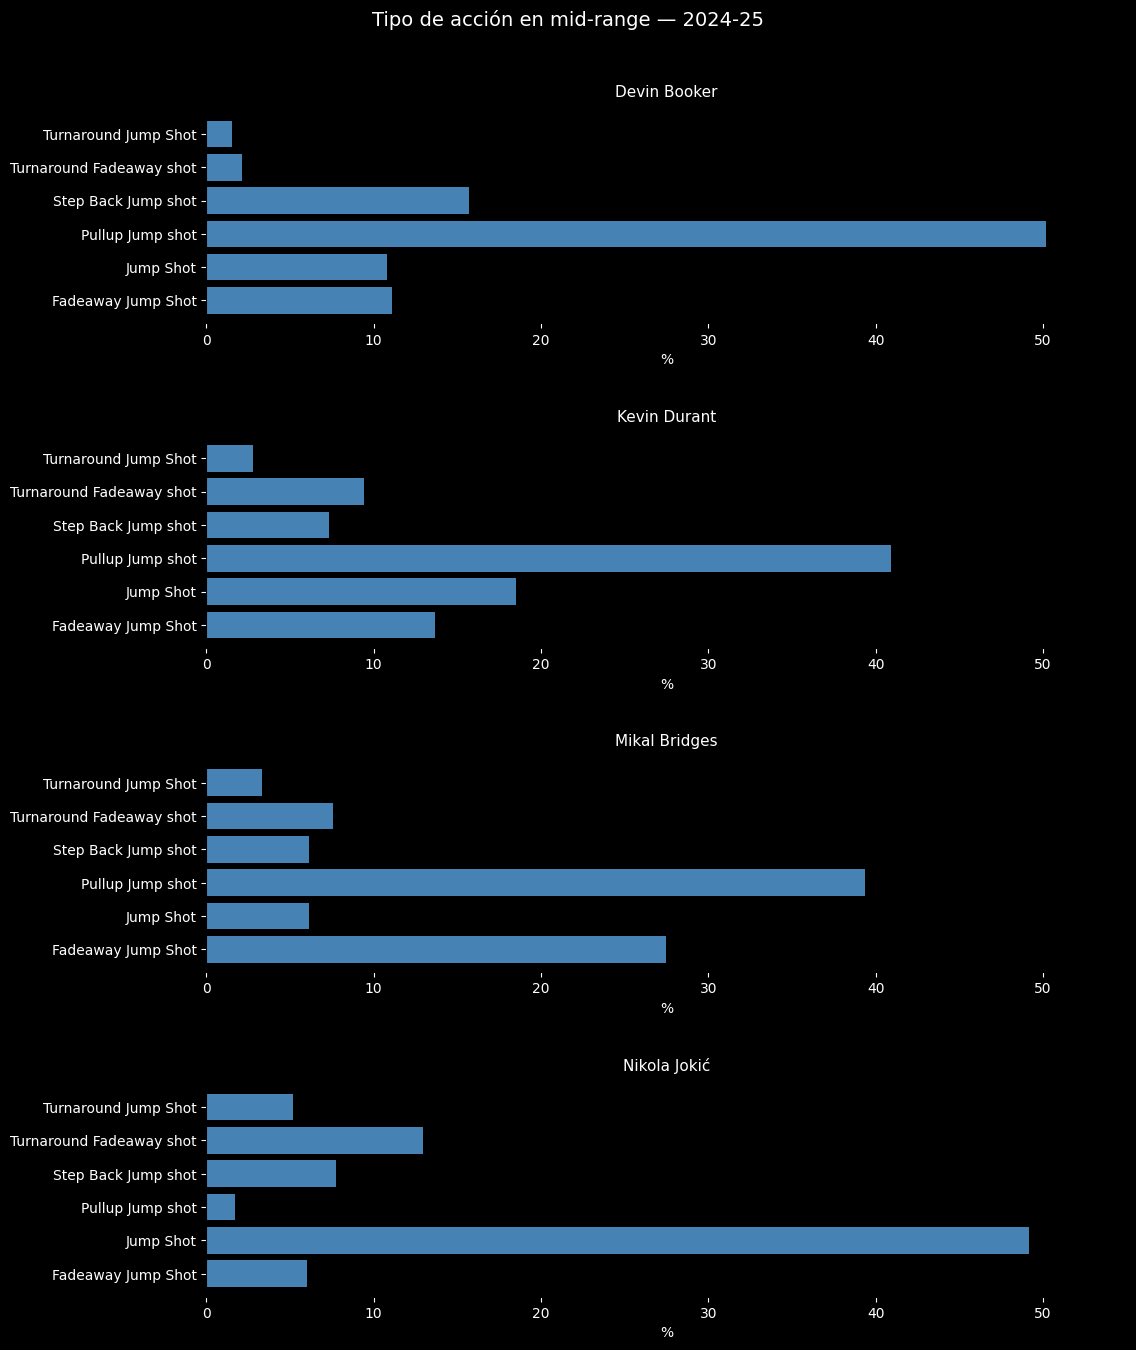

In [7]:
# Sacamos todos los tipos que aparecen con >= 5% en algún jugador porque es irrelevante
tipos_relevantes = tabla_acciones[tabla_acciones["PORCENTAJE"] >= 5]["ACTION_TYPE"].unique()

# Orden alfabético fijo para todos para que se vea mejor
tipos_relevantes = sorted(tipos_relevantes)

fig, axes = plt.subplots(4, 1, figsize=(12, 14))
fig.patch.set_facecolor("black")

jugadores_lista = ["Devin Booker", "Kevin Durant", "Mikal Bridges", "Nikola Jokić"]

for i, jugador in enumerate(jugadores_lista):
    ax = axes[i]
    ax.set_facecolor("black")
    
    datos = tabla_acciones[
        (tabla_acciones["PLAYER_NAME"] == jugador) &
        (tabla_acciones["ACTION_TYPE"].isin(tipos_relevantes))
    ].set_index("ACTION_TYPE").reindex(tipos_relevantes).fillna(0)
    
    ax.barh(tipos_relevantes, datos["PORCENTAJE"], color="steelblue")
    ax.set_title(jugador, color="white", fontsize=11, pad=10)
    ax.set_xlim(0, 55)
    ax.tick_params(colors="white")
    plt.setp(ax.get_xticklabels(), color="white")
    plt.setp(ax.get_yticklabels(), color="white")
    ax.set_xlabel("%", color="white")

plt.suptitle("Tipo de acción en mid-range — 2024-25", fontsize=14, color="white")
plt.tight_layout(pad=3.0)
plt.savefig("acciones_midrange.png", facecolor="black")
plt.show()

## Primeras conclusiones

### El tipo de acción y el tipo de jugador

Booker, Durant y Bridges tienen alto porcentaje en pullup jump shot. Esto quiere decir que, en el mid-rage, buscan activamente encestar.  
El más discordante entre estos tres es Booker. Lo más probable es que se deba a su posición, que es escolta, frente a dos aleros.  
Jokic no se parece en nada a los demás. Es un pívot, por lo que juega de espaldas al aro y por eso tiene una cantidad muy alta de turnarounds.

Vale la pena destacar que Kevin Durant es prácticamente sobresaliente en jump shot y en pullup jumpshot. Dice mucho de la calidad de anotador que es.

## Segundo análisis
### ¿Desde qué lado son más eficientes con cada tipo de acción?
### ¿En qué momento del partido encestan más?

In [8]:
# Hora de revisar los valores que nos interesan

df_mid["SHOT_ZONE_AREA"].value_counts()

SHOT_ZONE_AREA
Right Side(R)            329
Left Side(L)             232
Center(C)                179
Right Side Center(RC)    112
Left Side Center(LC)      86
Name: count, dtype: int64

In [9]:
# Volvemos a calcular la eficiencia, parecido al notebook 2

eficiencia_multi = df_mid.groupby(["PLAYER_NAME", "SHOT_ZONE_AREA", "ACTION_TYPE"]).agg(
    ATTEMPTS=("SHOT_MADE_FLAG", "count"),
    GOALS=("SHOT_MADE_FLAG", "sum")
).reset_index()

eficiencia_multi["PORCENTAJE"] = (eficiencia_multi["GOALS"] / eficiencia_multi["ATTEMPTS"] * 100).round(1)

# Filtramos intentos mínimos para que no salgan tiros raros con 1 intento y 100%
eficiencia_multi = eficiencia_multi[eficiencia_multi["ATTEMPTS"] >= 10]

eficiencia_multi.sort_values(["PLAYER_NAME", "SHOT_ZONE_AREA", "PORCENTAJE"], ascending=[True, True, False])

,PLAYER_NAME,SHOT_ZONE_AREA,ACTION_TYPE,ATTEMPTS,GOALS,PORCENTAJE
4,Devin Booker,Center(C),Pullup Jump shot,36,21,58.3
11,Devin Booker,Left Side Center(LC),Pullup Jump shot,26,15,57.7
22,Devin Booker,Left Side(L),Step Back Jump shot,12,7,58.3
20,Devin Booker,Left Side(L),Pullup Jump shot,36,19,52.8
29,Devin Booker,Right Side Center(RC),Pullup Jump shot,31,15,48.4
31,Devin Booker,Right Side Center(RC),Step Back Jump shot,11,5,45.5
37,Devin Booker,Right Side(R),Pullup Jump shot,34,21,61.8
35,Devin Booker,Right Side(R),Fadeaway Jump Shot,18,10,55.6
39,Devin Booker,Right Side(R),Step Back Jump shot,10,4,40.0
45,Kevin Durant,Center(C),Jump Shot,10,7,70.0


In [10]:
mejor_accion = eficiencia_multi.loc[
    eficiencia_multi.groupby(["PLAYER_NAME", "SHOT_ZONE_AREA"])["PORCENTAJE"].idxmax()
].reset_index(drop=True)

mejor_accion[["PLAYER_NAME", "SHOT_ZONE_AREA", "ACTION_TYPE", "PORCENTAJE"]]

,PLAYER_NAME,SHOT_ZONE_AREA,ACTION_TYPE,PORCENTAJE
0,Devin Booker,Center(C),Pullup Jump shot,58.3
1,Devin Booker,Left Side Center(LC),Pullup Jump shot,57.7
2,Devin Booker,Left Side(L),Step Back Jump shot,58.3
3,Devin Booker,Right Side Center(RC),Pullup Jump shot,48.4
4,Devin Booker,Right Side(R),Pullup Jump shot,61.8
5,Kevin Durant,Center(C),Jump Shot,70.0
6,Kevin Durant,Left Side Center(LC),Pullup Jump shot,41.7
7,Kevin Durant,Left Side(L),Pullup Jump shot,64.0
8,Kevin Durant,Right Side Center(RC),Pullup Jump shot,42.9
9,Kevin Durant,Right Side(R),Pullup Jump shot,65.1


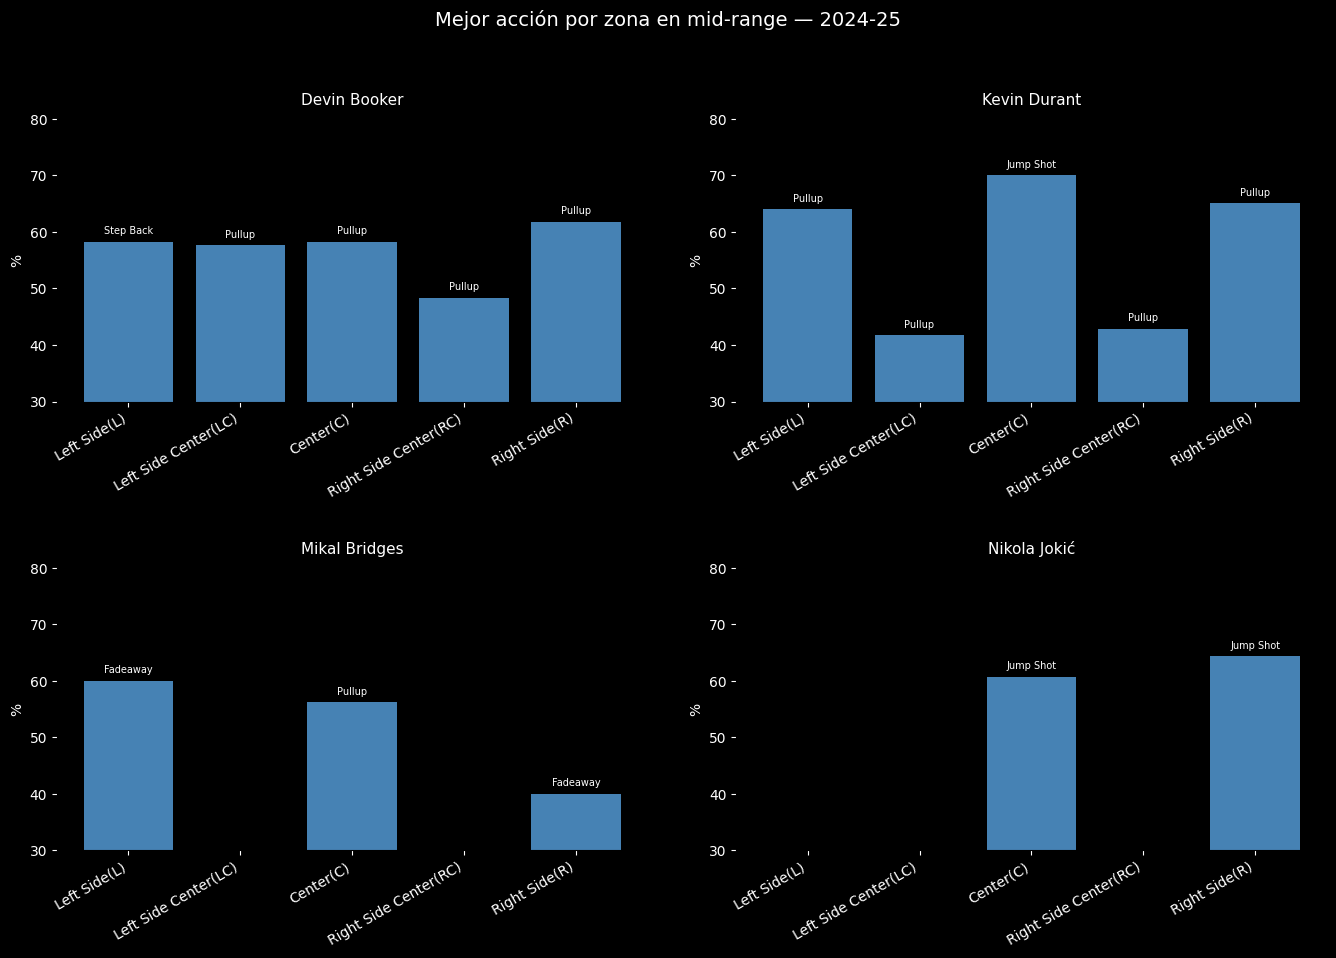

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor("black")
axes = axes.flatten()

zonas_orden = ["Left Side(L)", "Left Side Center(LC)", "Center(C)", "Right Side Center(RC)", "Right Side(R)"]
jugadores_lista = ["Devin Booker", "Kevin Durant", "Mikal Bridges", "Nikola Jokić"]

for i, jugador in enumerate(jugadores_lista):
    ax = axes[i]
    ax.set_facecolor("black")

    datos = mejor_accion[mejor_accion["PLAYER_NAME"] == jugador].set_index("SHOT_ZONE_AREA").reindex(zonas_orden)

    ax.bar(zonas_orden, datos["PORCENTAJE"].fillna(0), color="steelblue")

    # Etiqueta con el tipo de acción encima de cada barra
    for zona in zonas_orden:
        if zona in datos.index and not pd.isna(datos.loc[zona, "PORCENTAJE"]):
            ax.text(
                zona, datos.loc[zona, "PORCENTAJE"] + 1,
                datos.loc[zona, "ACTION_TYPE"].replace(" Jump Shot", "").replace(" Jump shot", ""),
                ha="center", va="bottom", color="white", fontsize=7
            )

    ax.set_title(jugador, color="white", fontsize=11, pad=10)
    ax.set_ylim(30, 80)
    ax.tick_params(colors="white")
    plt.setp(ax.get_xticklabels(), color="white", rotation=30, ha="right")
    plt.setp(ax.get_yticklabels(), color="white")
    ax.set_ylabel("%", color="white")

plt.suptitle("Mejor acción por zona en mid-range — 2024-25", fontsize=14, color="white")
plt.tight_layout(pad=3.0)
plt.savefig("mejor_accion_zona.png", facecolor="black")
plt.show()

## Conclusiones
### Se han analizado:
Zona + tipo de acción + eficiencia

### Sacamos en claro:
**Booker y Durant:** Dominan en casi todas las posiciones. Llama la atención que Durant domine como alero en el centro con jump shot.  
**Bridges:** Fadeaway en los laterales. Interesante.  
**Jokic:** El gráfico nos vuelve a demostrar que es un pívot. Recibe y tira. No hay más.  

## Último análisis
### ¿En qué momento del partido son más eficientes?

In [12]:
df["PERIOD"].value_counts()

PERIOD
1    1471
3    1467
2    1064
4    1032
5      54
6       3
Name: count, dtype: int64

In [13]:
# Agrupamos el tiempo 5 y 6 como OVERTIME
# Un poco engorroso hacer un mapeo, pero no se me ocurría otra manera

mapa_periodos = {1: "Q1", 2: "Q2", 3: "Q3", 4: "Q4", 5: "OVERTIME", 6: "OVERTIME"}
df["PERIOD_LABEL"] = df["PERIOD"].map(mapa_periodos)

df["PERIOD_LABEL"].value_counts()

PERIOD_LABEL
Q1          1471
Q3          1467
Q2          1064
Q4          1032
OVERTIME      57
Name: count, dtype: int64

In [15]:
# Volvemos a calcular la eficiencia
# Debería haber hecho una función de esto. Ya es tarde.

df_mid = df[df["SHOT_ZONE_BASIC"] == "Mid-Range"]

eficiencia_periodo = df_mid.groupby(["PLAYER_NAME", "PERIOD_LABEL"]).agg(
    ATTEMPTS=("SHOT_MADE_FLAG", "count"),
    GOALS=("SHOT_MADE_FLAG", "sum")
).reset_index()

eficiencia_periodo["PORCENTAJE"] = (eficiencia_periodo["GOALS"] / eficiencia_periodo["ATTEMPTS"] * 100).round(2)

eficiencia_periodo[["PLAYER_NAME", "PERIOD_LABEL", "ATTEMPTS", "PORCENTAJE"]]

,PLAYER_NAME,PERIOD_LABEL,ATTEMPTS,PORCENTAJE
0,Devin Booker,OVERTIME,1,100.00
1,Devin Booker,Q1,106,55.66
2,Devin Booker,Q2,69,47.83
3,Devin Booker,Q3,84,52.38
4,Devin Booker,Q4,65,47.69
5,Kevin Durant,OVERTIME,5,60.00
6,Kevin Durant,Q1,89,59.55
7,Kevin Durant,Q2,56,50.00
8,Kevin Durant,Q3,80,51.25
9,Kevin Durant,Q4,56,48.21


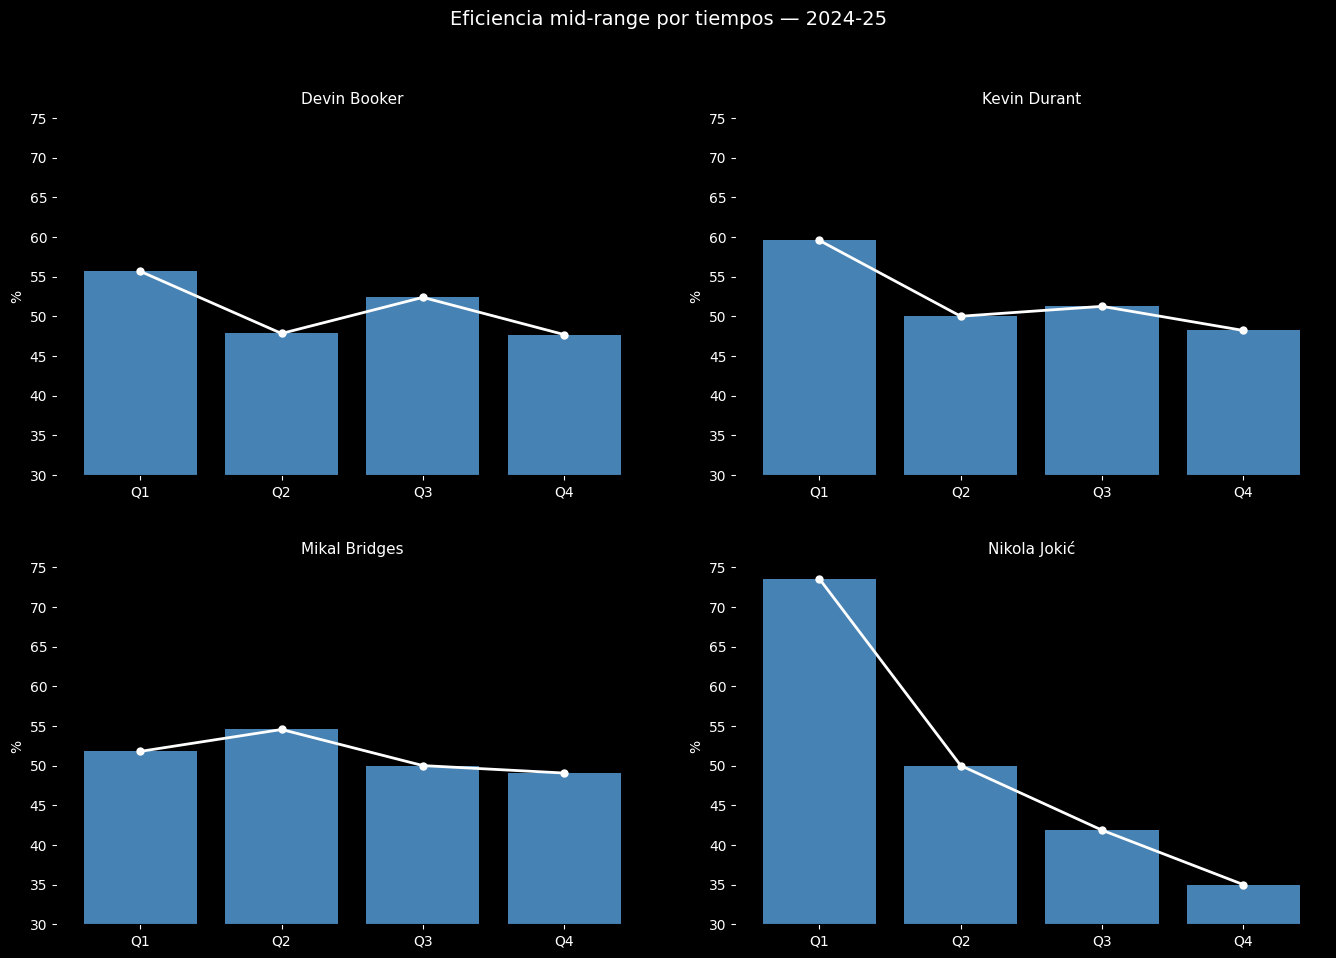

In [20]:
# VISUALIZACIÓN
# No sé por qué dejé el Overtime, pero lo quitamos ya

periodos_orden = ["Q1", "Q2", "Q3", "Q4"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor("black")
axes = axes.flatten()

jugadores_lista = ["Devin Booker", "Kevin Durant", "Mikal Bridges", "Nikola Jokić"]

for i, jugador in enumerate(jugadores_lista):
    ax = axes[i]
    ax.set_facecolor("black")

    datos = eficiencia_periodo[
        (eficiencia_periodo["PLAYER_NAME"] == jugador) &
        (eficiencia_periodo["PERIOD_LABEL"].isin(periodos_orden))
    ].set_index("PERIOD_LABEL").reindex(periodos_orden)

    ax.bar(periodos_orden, datos["PORCENTAJE"].fillna(0), color="steelblue")
    ax.plot(periodos_orden, datos["PORCENTAJE"].fillna(0), color="white", linewidth=2, marker="o", markersize=5)

    ax.set_title(jugador, color="white", fontsize=11, pad=10)
    ax.set_ylim(30, 75)
    ax.tick_params(colors="white")
    plt.setp(ax.get_xticklabels(), color="white")
    plt.setp(ax.get_yticklabels(), color="white")
    ax.set_ylabel("%", color="white")

plt.suptitle("Eficiencia mid-range por tiempos — 2024-25", fontsize=14, color="white")
plt.tight_layout(pad=3.0)
plt.savefig("eficiencia_periodo.png", facecolor="black")
plt.show()

## Conclusiones
#### Recordemos que esto es solo en mid-range
**Booker y Durant**: Buenísimos en el primer tiempo, pero caen ambos en Q2 y remontan en Q3.
**Bridges**: Empieza algo flojo, se levanta en Q2, pero en general es estable.
**Jokic**: Desempeño increíble en Q1 y caída en picado hasta Q4. Viendo el historial del jugador, podemos deducir que: se cansa.  
Jokic es bien conocido por no ser el más atlético ni el que más empeño le pone a ese aspecto en la NBA. Para él, jugar es como ir a trabajar. Desempeña su labor y marcha a casa.
